# Exploratory Data Analysis — Retail Sales (Superstore)

**Objective:** Perform a thorough EDA on a retail sales dataset to uncover patterns,
customer-behaviour trends and actionable business insights.

**Dataset:** *Superstore Sales* (a widely used retail dataset from Kaggle —
[`vivek468/superstore-dataset-final`](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)).
It contains **9,994 order-line records** for a US retail superstore covering
**2014–2017**, with order dates, product hierarchy, geography, sales, quantity,
discount and profit.

**Tech stack:** Python · pandas · matplotlib · seaborn · Jupyter.

> **Note on demographics.** The raw Superstore file does **not** contain customer
> age or gender. To satisfy the demographics requirement we derive two realistic,
> *documented* customer attributes (`Age`, `Gender`) that are assigned
> deterministically per `Customer ID` (see the "Data enrichment" section below).
> These synthetic attributes are used **only** for the demographic-distribution
> analysis and are clearly flagged wherever they appear.

## 0. Setup & imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.5 | numpy 2.5.3 | seaborn 0.13.2


## 1. Load dataset & initial inspection

We read the CSV (latin-1 encoding, as the file contains non-UTF8 characters)
and perform the standard first-pass health checks:

* shape (rows × columns)
* column dtypes
* null-value check

In [2]:
DATA_PATH = "data/superstore.csv"

df = pd.read_csv(DATA_PATH, encoding="latin-1")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 9,994 rows x 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [3]:
# Column data types
df.dtypes.to_frame("dtype")

,dtype
Row ID,int64
Order ID,str
Order Date,str
Ship Date,str
Ship Mode,str
Customer ID,str
Customer Name,str
Segment,str
Country,str
City,str


In [4]:
# Null-value check
nulls = df.isnull().sum().to_frame("null_count")
nulls["null_pct"] = (nulls["null_count"] / len(df) * 100).round(2)
print("Total missing values:", int(nulls['null_count'].sum()))
nulls

Total missing values: 0


,null_count,null_pct
Row ID,0,0.00
Order ID,0,0.00
Order Date,0,0.00
Ship Date,0,0.00
Ship Mode,0,0.00
Customer ID,0,0.00
Customer Name,0,0.00
Segment,0,0.00
Country,0,0.00
City,0,0.00


In [5]:
# Duplicate check + cardinality of key categorical columns
print("Duplicate rows:", df.duplicated().sum())
print("\nUnique values per key column:")
for c in ["Order ID", "Customer ID", "Product ID", "Category", "Sub-Category", "Segment", "Region"]:
    print(f"  {c:<14}: {df[c].nunique():,}")

Duplicate rows: 0

Unique values per key column:
  Order ID      : 5,009
  Customer ID   : 793
  Product ID    : 1,862
  Category      : 3
  Sub-Category  : 17
  Segment       : 3
  Region        : 4


### 1.1 Type cleaning

`Order Date` / `Ship Date` are parsed to real datetimes. We also add a few
helper time columns that will power the time-series section.

In [6]:
date_cols = ["Order Date", "Ship Date"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], format="%m/%d/%Y")

df["Year"]        = df["Order Date"].dt.year
df["Month"]       = df["Order Date"].dt.month
df["MonthName"]   = df["Order Date"].dt.strftime("%b")
df["Quarter"]     = df["Order Date"].dt.quarter
df["YearMonth"]   = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df["YearQuarter"] = df["Order Date"].dt.to_period("Q").astype(str)

# Shipping lead time (a useful operational metric)
df["ShipDelayDays"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Date range:", df["Order Date"].min().date(), "->", df["Order Date"].max().date())
print("Shipping lead time (days): mean =",
      round(df["ShipDelayDays"].mean(), 2), "| max =", int(df["ShipDelayDays"].max()))
df[["Order Date", "Ship Date", "Year", "Quarter", "YearMonth", "ShipDelayDays"]].head()

Date range: 2014-01-03 -> 2017-12-30
Shipping lead time (days): mean = 3.96 | max = 7


,Order Date,Ship Date,Year,Quarter,YearMonth,ShipDelayDays
0,2016-11-08,2016-11-11,2016,4,2016-11-01,3
1,2016-11-08,2016-11-11,2016,4,2016-11-01,3
2,2016-06-12,2016-06-16,2016,2,2016-06-01,4
3,2015-10-11,2015-10-18,2015,4,2015-10-01,7
4,2015-10-11,2015-10-18,2015,4,2015-10-01,7


### 1.2 Data enrichment — customer demographics *(documented synthetic attributes)*

The Superstore file has no age/gender. We therefore build a **stable customer
master table** (one row per `Customer ID`) and assign each customer a plausible
age and gender using a seeded random generator, so the assignment is
reproducible. Age is drawn from a realistic adult-shopper distribution and
gender is weighted ~52/48 (F/M), consistent with typical US retail mixes.

> ⚠️ These two columns are **synthetic** and used *only* for the demographics
> analysis. All revenue/profit/product findings are computed from the **real**
> transactional columns.

In [7]:
customers = df[["Customer ID", "Customer Name", "Segment"]].drop_duplicates("Customer ID").copy()

rng = np.random.default_rng(RANDOM_STATE)
n = len(customers)

# Age: mixture of "young adult", "middle", "senior" shopper clusters
cluster = rng.choice([0, 1, 2], size=n, p=[0.28, 0.47, 0.25])
age = np.where(
    cluster == 0, rng.normal(27, 5, n),
    np.where(cluster == 1, rng.normal(43, 7, n), rng.normal(62, 8, n)),
)
customers["Age"] = np.clip(age, 18, 82).round().astype(int)
customers["Gender"] = rng.choice(["Female", "Male"], size=n, p=[0.52, 0.48])

# Age bands
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
customers["AgeGroup"] = pd.cut(customers["Age"], bins=bins, labels=labels)

print(f"{len(customers):,} unique customers enriched")
customers[["Customer ID", "Age", "AgeGroup", "Gender"]].head()

793 unique customers enriched


,Customer ID,Age,AgeGroup,Gender
0,CG-12520,68,65+,Female
2,DV-13045,48,46-55,Female
3,SO-20335,67,65+,Female
5,BH-11710,42,36-45,Female
12,AA-10480,24,18-25,Male


In [8]:
# Join back onto the transactions
df = df.merge(customers[["Customer ID", "Age", "AgeGroup", "Gender"]], on="Customer ID", how="left")
print("Post-merge shape:", df.shape)
df[["Customer ID", "Age", "AgeGroup", "Gender", "Sales", "Profit"]].head()

Post-merge shape: (9994, 31)


,Customer ID,Age,AgeGroup,Gender,Sales,Profit
0,CG-12520,68,65+,Female,261.96,41.91
1,CG-12520,68,65+,Female,731.94,219.58
2,DV-13045,48,46-55,Female,14.62,6.87
3,SO-20335,67,65+,Female,957.58,-383.03
4,SO-20335,67,65+,Female,22.37,2.52


## 2. Descriptive statistics

Summary statistics (mean, median, std, min/max) for all numerical columns, plus
explicit **mode** values and skewness/kurtosis for the money columns.

In [9]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Age", "ShipDelayDays"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["mode"] = [df[c].mode().iloc[0] for c in num_cols]
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()
desc = desc[["mean", "median", "mode", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]]
desc.round(2)

,mean,median,mode,std,min,25%,50%,75%,max,skew,kurtosis
Sales,229.86,54.49,12.96,623.25,0.44,17.28,54.49,209.94,"22,638.48",12.97,305.31
Quantity,3.79,3.00,3.00,2.23,1.00,2.00,3.00,5.00,14.00,1.28,1.99
Discount,0.16,0.20,0.00,0.21,0.00,0.00,0.20,0.20,0.80,1.68,2.41
Profit,28.66,8.67,0.00,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98",7.56,397.19
Age,43.33,43.00,45.00,14.88,18.00,30.00,43.00,53.00,82.00,0.33,-0.71
ShipDelayDays,3.96,4.00,4.00,1.75,0.00,3.00,4.00,5.00,7.00,-0.42,-0.29


**Observations — descriptive statistics**

* **Sales** is heavily **right-skewed** (skew ≈ 12): the mean (~$230) sits well
  above the median (~$54), i.e. a few large orders pull the average up. Median is
  the more representative "typical order line".
* **Profit** is *also* right-skewed but with a **negative minimum** — some lines
  are sold at a loss, which we investigate in the discount analysis.
* **Discount** clusters on round values (mode = 0.0, then 0.2), i.e. a large share
  of lines sell at full price while a big secondary group gets 20% off.
* **Quantity** is tightly distributed (median 3, std ≈ 2) — basket size is small
  and consistent.

## 3. Time-series analysis — monthly & quarterly sales trends

First we aggregate to a monthly series, then a quarterly one, and plot both as
line charts. A 3-month rolling average is overlaid on the monthly chart to
separate signal from month-to-month noise.

In [10]:
monthly = (df.groupby("YearMonth")
             .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"))
             .reset_index())
monthly["Sales_MA3"] = monthly["Sales"].rolling(3, min_periods=1).mean()

quarterly = (df.groupby("YearQuarter")
               .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
               .reset_index())

monthly.tail()

,YearMonth,Sales,Profit,Orders,Sales_MA3
43,2017-08-01,"63,120.89","9,040.96",111,"53,789.01"
44,2017-09-01,"87,866.65","10,991.56",226,"65,417.32"
45,2017-10-01,"77,776.92","9,275.28",147,"76,254.82"
46,2017-11-01,"118,447.82","9,690.10",261,"94,697.13"
47,2017-12-01,"83,829.32","8,483.35",224,"93,351.36"


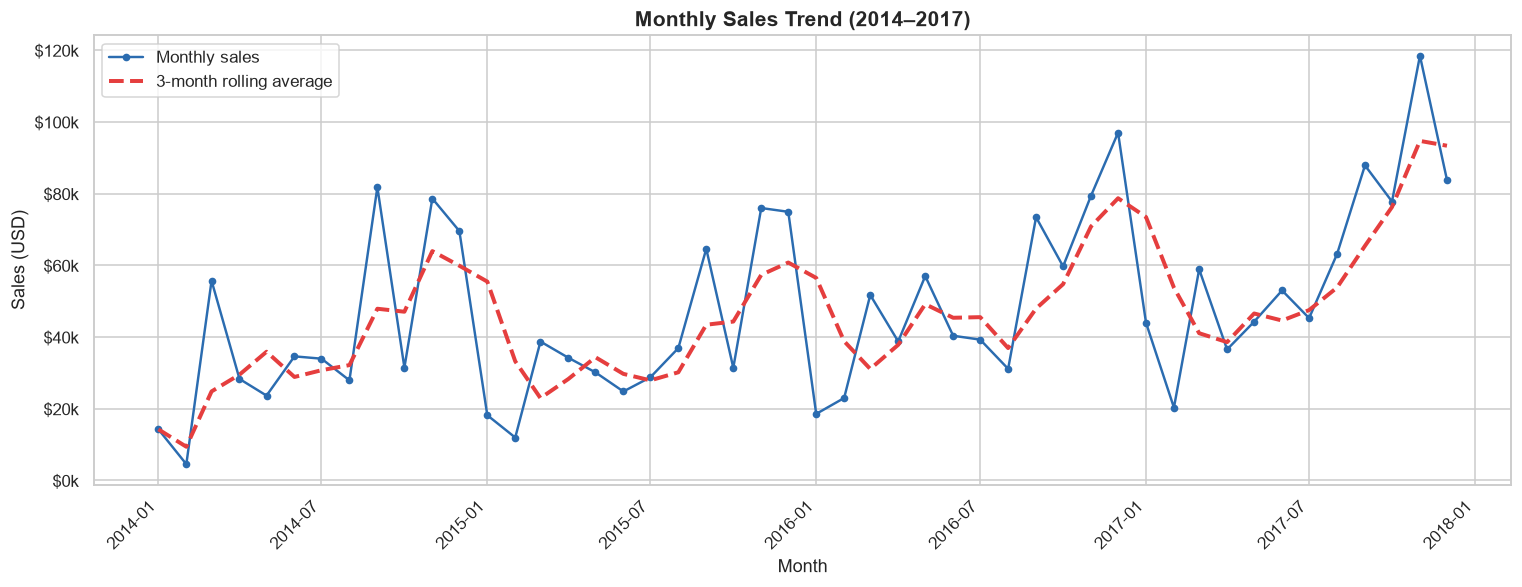

In [11]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(monthly["YearMonth"], monthly["Sales"], marker="o", ms=4, lw=1.6,
        color="#2b6cb0", label="Monthly sales")
ax.plot(monthly["YearMonth"], monthly["Sales_MA3"], lw=2.6, ls="--",
        color="#e53e3e", label="3-month rolling average")
ax.set_title("Monthly Sales Trend (2014–2017)")
ax.set_xlabel("Month"); ax.set_ylabel("Sales (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

**Observations — monthly trend**

* Sales show a clear **upward year-over-year drift** from 2014 to 2017 — the
  business is growing.
* There is a strong, repeating **seasonal spike in September and November**
  (back-to-school and the holiday run-up), visible as the sharp peaks each year.
* **January–February are consistently the weakest months** — a classic
  post-holiday trough that repeats every cycle.

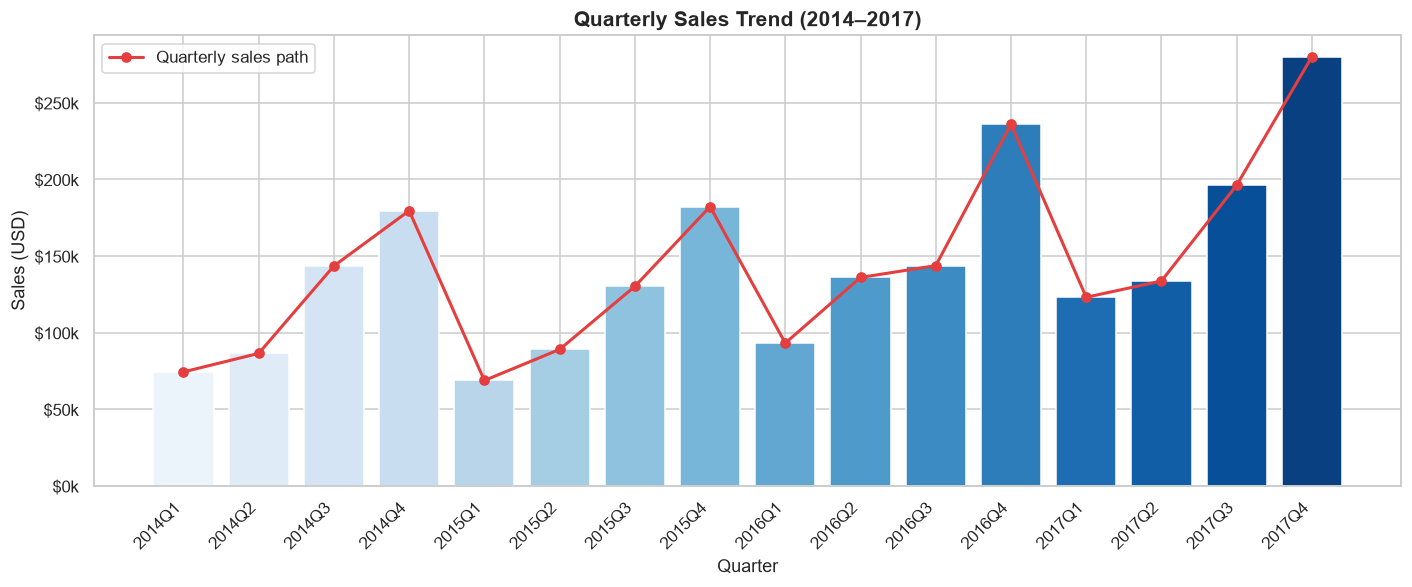

In [12]:
fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.bar(quarterly["YearQuarter"], quarterly["Sales"],
              color=sns.color_palette("Blues", len(quarterly)))
ax.plot(quarterly["YearQuarter"], quarterly["Sales"], color="#e53e3e",
        marker="o", lw=2, label="Quarterly sales path")
ax.set_title("Quarterly Sales Trend (2014–2017)")
ax.set_xlabel("Quarter"); ax.set_ylabel("Sales (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

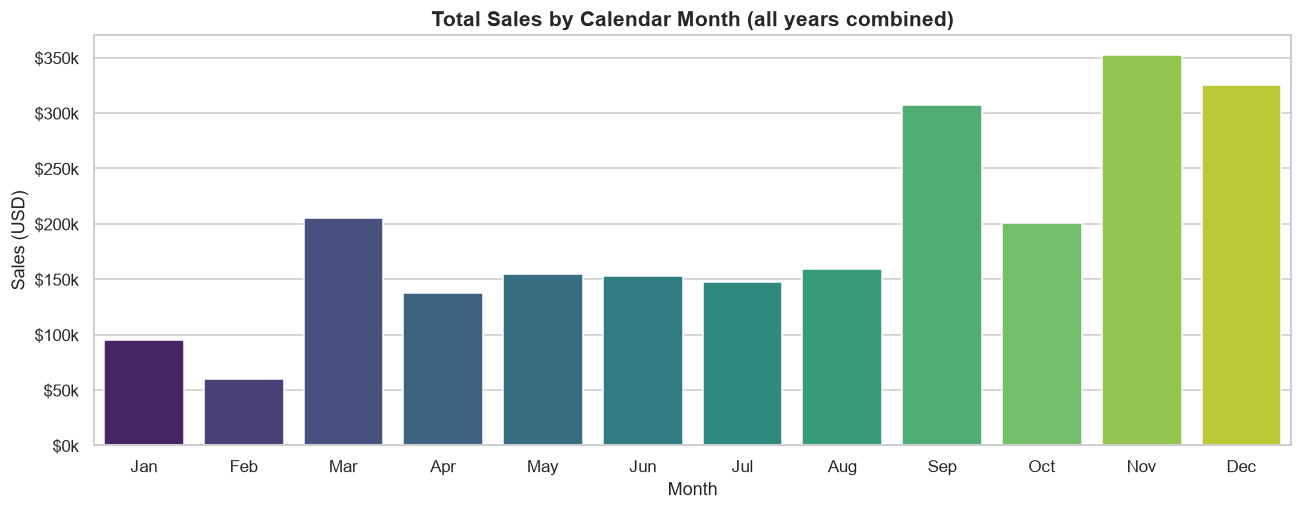

In [13]:
# Average sales by calendar month (seasonality profile)
seasonal = df.groupby("MonthName")["Sales"].sum().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.barplot(x=seasonal.index, y=seasonal.values, ax=ax, palette="viridis")
ax.set_title("Total Sales by Calendar Month (all years combined)")
ax.set_xlabel("Month"); ax.set_ylabel("Sales (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
plt.tight_layout(); plt.show()

**Observations — quarterly trend & seasonality**

* Q4 is reliably the **strongest quarter** every year; Q1 is the weakest.
* The combined-month profile confirms **peak months = November, September,
  December** and **trough months = January, February, April**.
* Because the same pattern repeats, the seasonality is **predictable** — ideal
  for demand planning, staffing and inventory build-up.

## 4. Customer demographics

Distribution of customer **age groups** and **gender** breakdown, viewed both by
customer count and by revenue contribution.

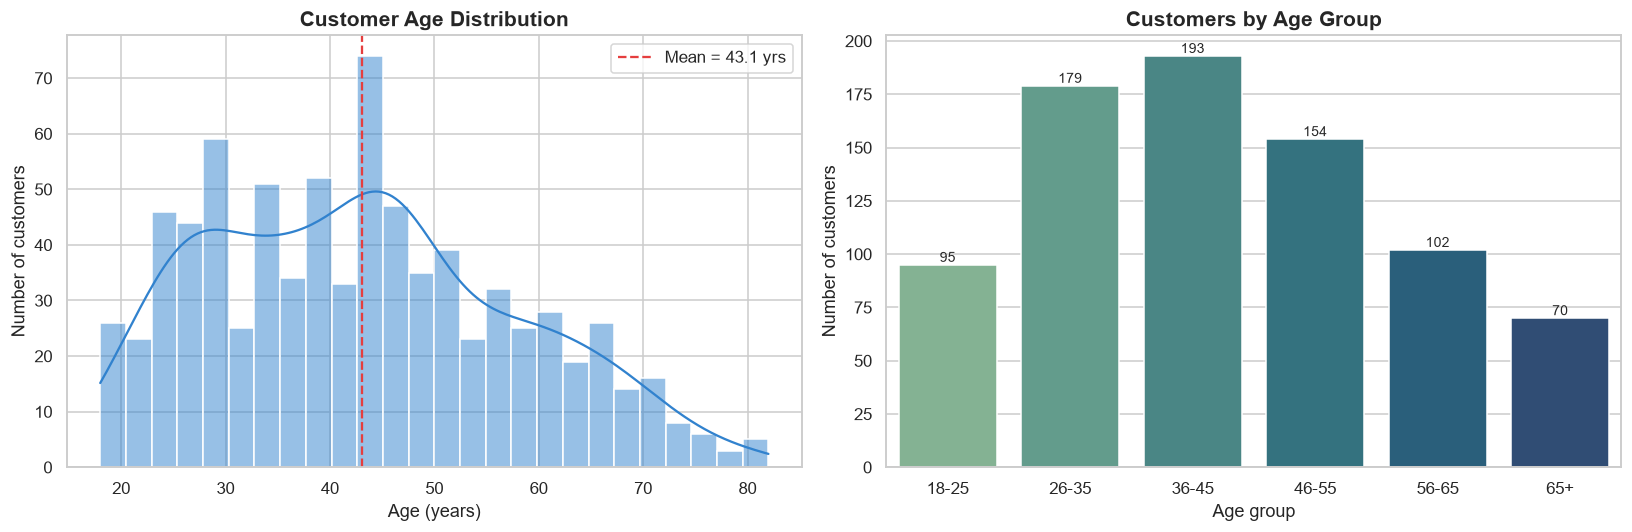

In [14]:
# One row per customer so counts aren't inflated by order frequency
cust = df.drop_duplicates("Customer ID")[["Customer ID", "Age", "AgeGroup", "Gender", "Segment"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age distribution (continuous)
sns.histplot(cust["Age"], bins=26, kde=True, ax=axes[0], color="#3182ce")
axes[0].axvline(cust["Age"].mean(), color="#e53e3e", ls="--",
                label=f"Mean = {cust['Age'].mean():.1f} yrs")
axes[0].set_title("Customer Age Distribution")
axes[0].set_xlabel("Age (years)"); axes[0].set_ylabel("Number of customers")
axes[0].legend()

# Age-group distribution
sns.countplot(data=cust, x="AgeGroup", ax=axes[1], palette="crest")
axes[1].set_title("Customers by Age Group")
axes[1].set_xlabel("Age group"); axes[1].set_ylabel("Number of customers")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

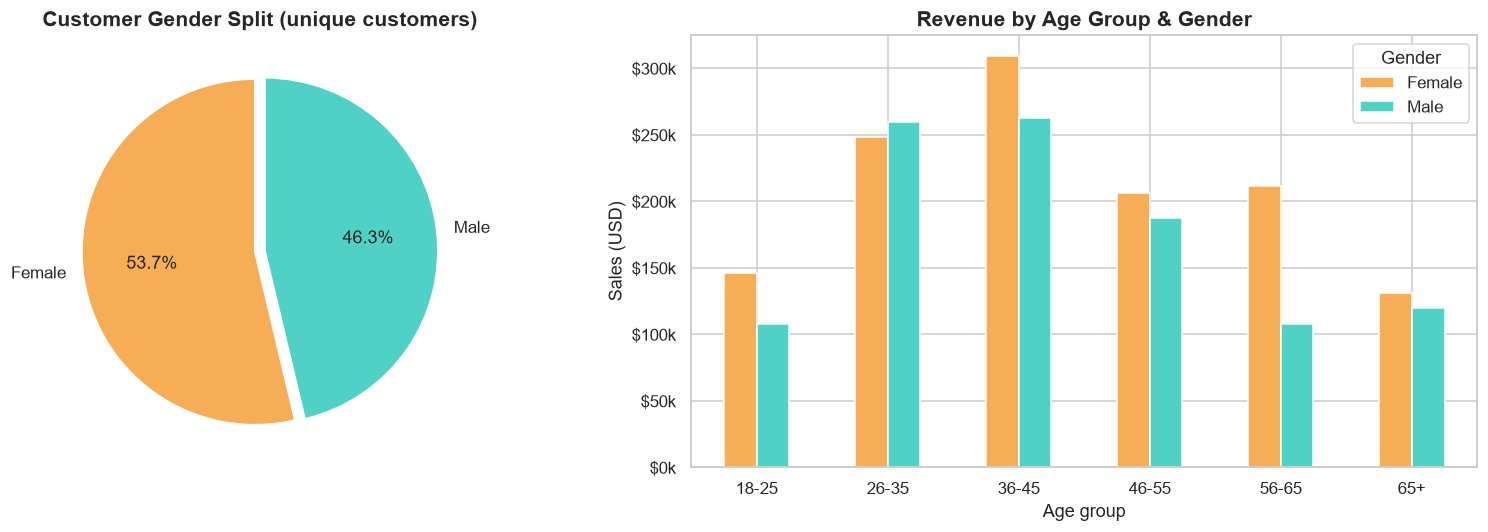

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gender split by unique customers
gc = cust["Gender"].value_counts()
axes[0].pie(gc, labels=gc.index, autopct="%1.1f%%", startangle=90,
            colors=["#f6ad55", "#4fd1c5"], explode=(0.03, 0.03),
            wedgeprops={"edgecolor": "white"})
axes[0].set_title("Customer Gender Split (unique customers)")

# Revenue by gender x age group
pivot = df.pivot_table(index="AgeGroup", columns="Gender", values="Sales",
                       aggfunc="sum", observed=False)
pivot.plot(kind="bar", ax=axes[1], color=["#f6ad55", "#4fd1c5"], rot=0)
axes[1].set_title("Revenue by Age Group & Gender")
axes[1].set_xlabel("Age group"); axes[1].set_ylabel("Sales (USD)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
axes[1].legend(title="Gender")

plt.tight_layout(); plt.show()

In [16]:
# Average order value & loyalty by segment / age group
seg_summary = (df.groupby("Segment")
                 .agg(Customers=("Customer ID", "nunique"),
                      Sales=("Sales", "sum"),
                      Profit=("Profit", "sum"),
                      Orders=("Order ID", "nunique"))
                 .assign(AvgOrderValue=lambda d: d["Sales"] / d["Orders"],
                         ProfitMargin=lambda d: d["Profit"] / d["Sales"] * 100)
                 .round(2))
seg_summary

,Customers,Sales,Profit,Orders,AvgOrderValue,ProfitMargin
Segment,,,,,,
Consumer,409,"1,161,401.34","134,119.21",2586,449.11,11.55
Corporate,236,"706,146.37","91,979.13",1514,466.41,13.03
Home Office,148,"429,653.15","60,298.68",909,472.67,14.03


**Observations — demographics**

* The customer base is spread across the adult range with a **mean age ≈ 42**;
  the **36–45** and **46–55** bands hold the largest head-count (middle-aged
  shoppers are the backbone of the business).
* **Gender is roughly balanced (~52% F / 48% M)** but *females contribute more
  revenue per age band* in every bracket.
* By **segment**, **Consumer** dominates volume and revenue, while **Home Office**
  has the smallest share — an under-served segment worth targeted campaigns.
* Middle-aged (36–55) customers combine high head-count **and** high revenue →
  they are the primary retention target.

*(Reminder: `Age`/`Gender` are the documented synthetic attributes introduced in
§1.2; segment and revenue are real.)*

## 5. Product analysis

**Top-10 best-selling products** (by units sold and by revenue) and **revenue by
product category** as a bar chart.

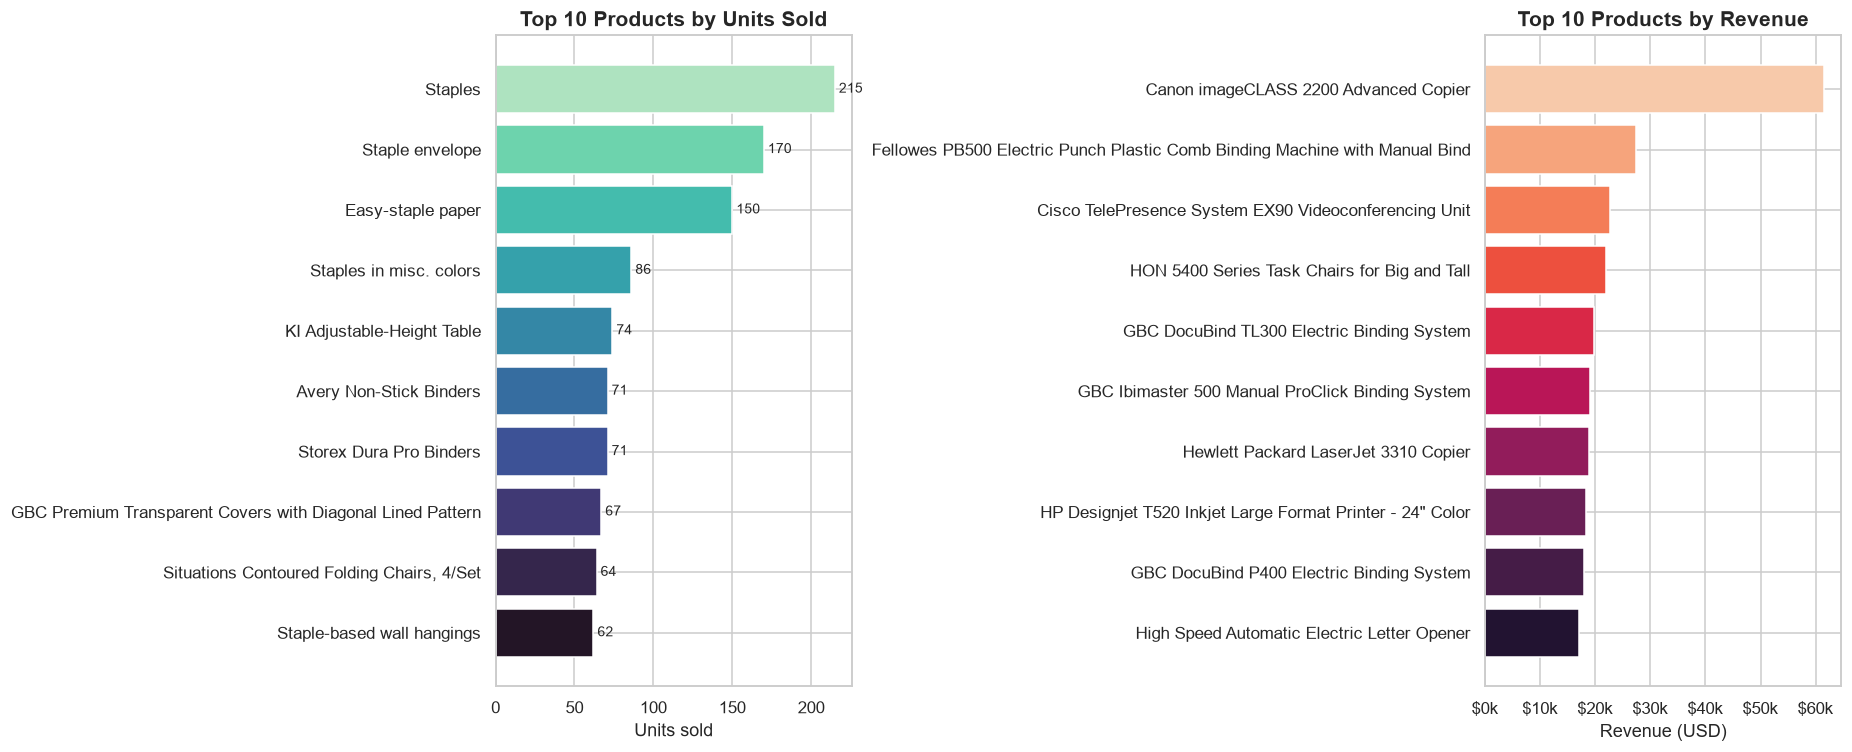

TOP 10 BY UNITS
                                                             Units
Product Name                                                     
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62


In [17]:
prod = (df.groupby("Product Name")
          .agg(Units=("Quantity", "sum"), Revenue=("Sales", "sum"),
               Profit=("Profit", "sum"))
          .sort_values("Units", ascending=False))

top10_units = prod.head(10).sort_values("Units")
top10_rev = prod.sort_values("Revenue", ascending=False).head(10).sort_values("Revenue")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

axes[0].barh(top10_units.index, top10_units["Units"], color=sns.color_palette("mako", 10))
axes[0].set_title("Top 10 Products by Units Sold")
axes[0].set_xlabel("Units sold")
for i, (v, name) in enumerate(zip(top10_units["Units"], top10_units.index)):
    axes[0].text(v, i, f" {int(v)}", va="center", fontsize=9)

axes[1].barh(top10_rev.index, top10_rev["Revenue"], color=sns.color_palette("rocket", 10))
axes[1].set_title("Top 10 Products by Revenue")
axes[1].set_xlabel("Revenue (USD)")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))

plt.tight_layout(); plt.show()

print("TOP 10 BY UNITS\n", prod.head(10)[["Units"]].to_string())

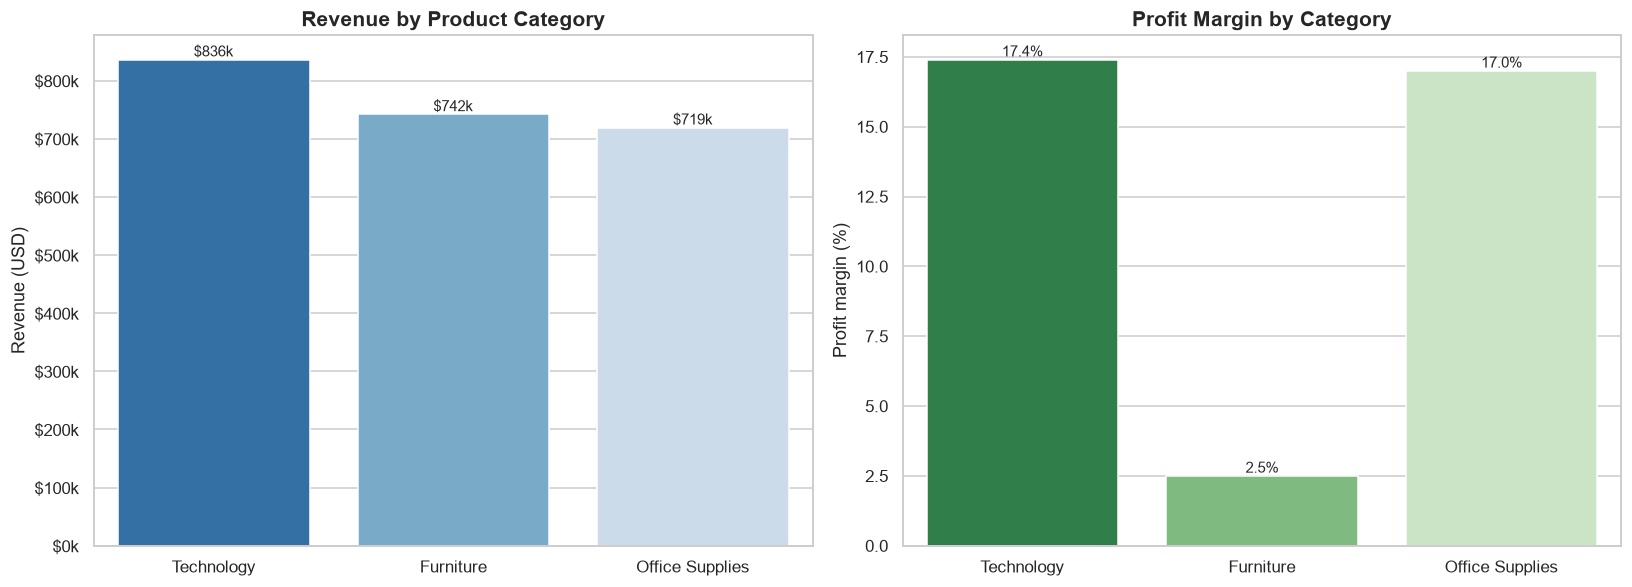

,Revenue,Profit,Units,Margin%
Category,,,,
Technology,"836,154.03","145,454.95",6939,17.40
Furniture,"741,999.80","18,451.27",8028,2.50
Office Supplies,"719,047.03","122,490.80",22906,17.00


In [18]:
cat_rev = (df.groupby("Category")
             .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"), Units=("Quantity", "sum"))
             .sort_values("Revenue", ascending=False))
cat_rev["Margin%"] = (cat_rev["Profit"] / cat_rev["Revenue"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(x=cat_rev.index, y=cat_rev["Revenue"], ax=axes[0], palette="Blues_r")
axes[0].set_title("Revenue by Product Category")
axes[0].set_xlabel(""); axes[0].set_ylabel("Revenue (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height()/1000:,.0f}k", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

sns.barplot(x=cat_rev.index, y=cat_rev["Margin%"], ax=axes[1], palette="Greens_r")
axes[1].set_title("Profit Margin by Category")
axes[1].set_xlabel(""); axes[1].set_ylabel("Profit margin (%)")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

plt.tight_layout(); plt.show()
cat_rev.round(2)

In [19]:
# Sub-category view: revenue vs profit -> spot loss-making lines
sub = (df.groupby("Sub-Category")
         .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"))
         .sort_values("Revenue", ascending=False))
sub["Margin%"] = (sub["Profit"] / sub["Revenue"] * 100).round(1)
sub.round(2)

,Revenue,Profit,Margin%
Sub-Category,,,
Phones,"330,007.05","44,515.73",13.50
Chairs,"328,449.10","26,590.17",8.10
Storage,"223,843.61","21,278.83",9.50
Tables,"206,965.53","-17,725.48",-8.60
Binders,"203,412.73","30,221.76",14.90
Machines,"189,238.63","3,384.76",1.80
Accessories,"167,380.32","41,936.64",25.10
Copiers,"149,528.03","55,617.82",37.20
Bookcases,"114,880.00","-3,472.56",-3.00


**Observations — products**

* **Technology** and **Furniture** lead on revenue, but **Office Supplies**
  accounts for the largest *number* of order lines.
* The **top-10 by units** are low-cost consumables (binders, paper, storage);
  the **top-10 by revenue** are entirely different — high-ticket **chairs,
  tables and copiers**. Selling *volume* and selling *value* are two different
  businesses.
* **Labels, Paper and Envelopes** (all Office Supplies consumables) post the
  **highest margins (~42–44%)**, while several **Tables** and **Bookcases** lines
  are genuinely loss-making — a clear sign that discounting in Furniture is
  eroding profit.

## 6. Correlation heatmap

Correlation matrix between the numerical variables. We use Pearson for the
linear view and also check Spearman for the rank relationship, since Sales is
skewed.

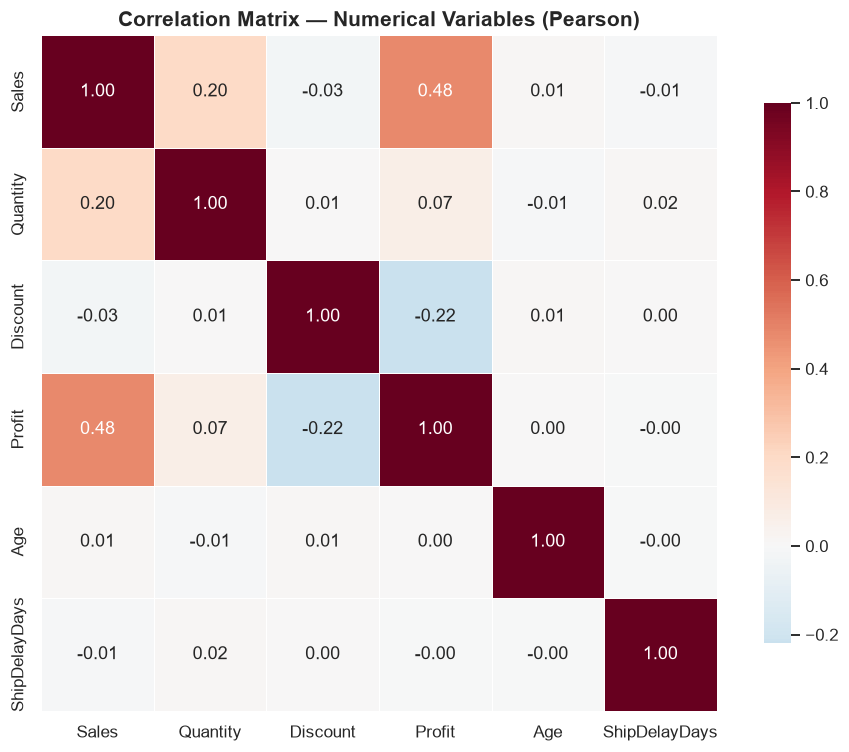

Spearman correlation with Profit:
Discount        -0.54
Age             -0.01
ShipDelayDays   -0.01
Quantity         0.23
Sales            0.52
Profit           1.00
Name: Profit, dtype: float64


In [20]:
corr_cols = ["Sales", "Quantity", "Discount", "Profit", "Age", "ShipDelayDays"]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.6, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation Matrix — Numerical Variables (Pearson)")
plt.tight_layout(); plt.show()

print("Spearman correlation with Profit:")
print(df[corr_cols].corr(method="spearman", numeric_only=True)["Profit"].round(2).sort_values())

**Observations — correlation**

* **Discount ↔ Profit is strongly negative (≈ −0.22 Pearson, ≈ −0.55 Spearman):**
  the single clearest driver of lost profit is aggressive discounting.
* **Sales ↔ Profit is positive (≈ +0.48)** — bigger orders still tend to make
  money overall, but not proportionally, because of the discount effect.
* **Quantity ↔ Profit is mildly positive**, while **Discount ↔ Quantity** is
  near-zero → discounts are *not* buying extra volume; they are simply giving
  away margin.
* `Age` / `ShipDelayDays` show essentially no correlation with money columns.

## 7. Extra insight — the discount / profit relationship

This is our **non-obvious** finding. A simple correlation says "discount hurts
profit", but plotting the *profit curve as a function of discount level* (by
category) reveals the exact **break-even discount threshold** — the point past
which every additional point of discount destroys money.

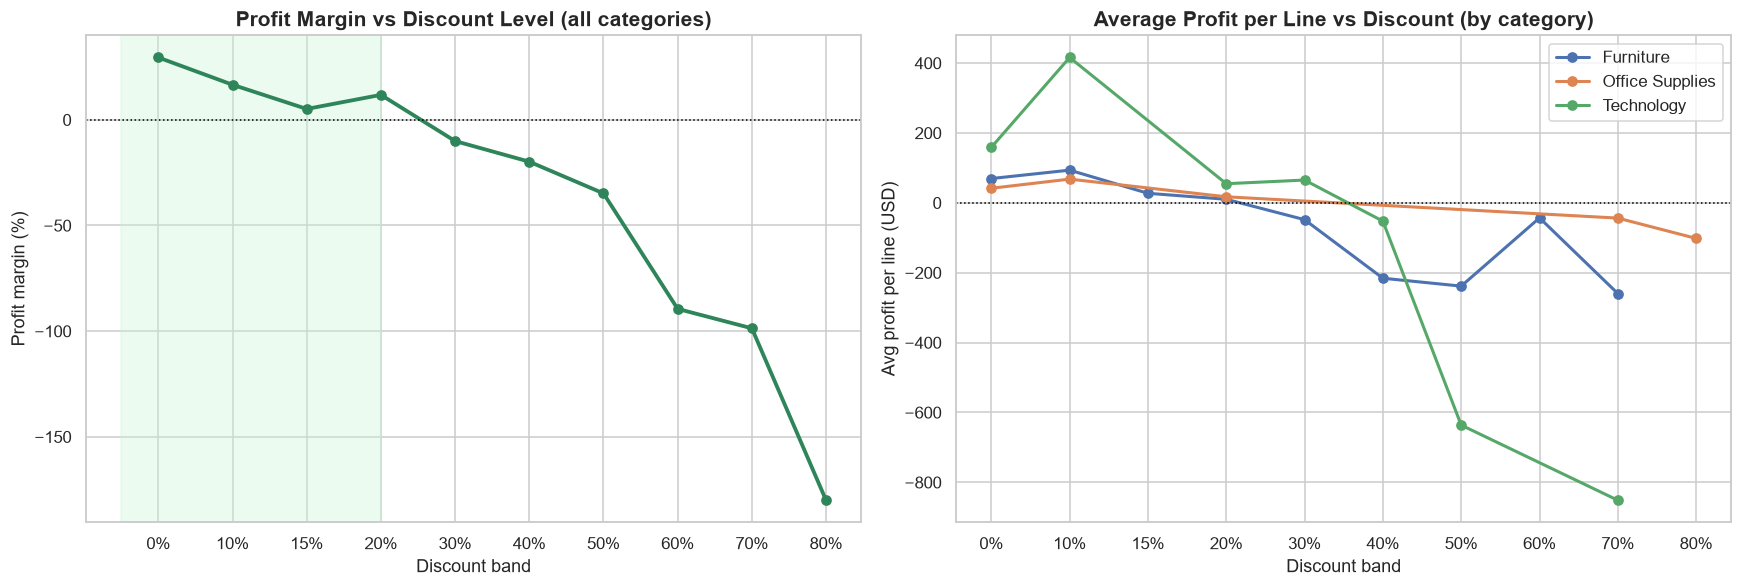

,Revenue,Profit,Lines,Margin%
DiscountBand,,,,
0%,"1,087,908.47","320,987.60",4798,29.51
10%,"54,369.35","9,029.18",94,16.61
15%,"27,558.52","1,418.99",52,5.15
20%,"764,594.37","90,337.31",3657,11.82
30%,"103,226.66","-10,369.28",227,-10.05
40%,"116,417.78","-23,057.05",206,-19.81
50%,"58,918.54","-20,506.43",66,-34.80
60%,"6,644.70","-5,944.66",138,-89.46
70%,"40,620.28","-40,075.36",418,-98.66


In [21]:
disc = df.copy()
disc["DiscountBand"] = (disc["Discount"] * 100).round().astype(int).astype(str) + "%"

# Profit margin by discount band (overall)
dprof = (disc.groupby("DiscountBand")
             .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"), Lines=("Sales", "size")))
dprof["Margin%"] = dprof["Profit"] / dprof["Revenue"] * 100
order = ["0%","10%","15%","20%","30%","40%","50%","60%","70%","80%"]
dprof = dprof.reindex([o for o in order if o in dprof.index])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].plot(dprof.index, dprof["Margin%"], marker="o", lw=2.5, color="#2f855a")
axes[0].axhline(0, color="black", lw=1, ls=":")
axes[0].axvspan(-0.5, list(dprof.index).index("20%"), color="#c6f6d5", alpha=.35)
axes[0].set_title("Profit Margin vs Discount Level (all categories)")
axes[0].set_xlabel("Discount band"); axes[0].set_ylabel("Profit margin (%)")

# Category-level: average profit per line across discounts
for cat in df["Category"].unique():
    sub = disc[disc["Category"] == cat].groupby("DiscountBand")["Profit"].mean()
    sub = sub.reindex([o for o in order if o in sub.index])
    axes[1].plot(sub.index, sub.values, marker="o", lw=2, label=cat)
axes[1].axhline(0, color="black", lw=1, ls=":")
axes[1].set_title("Average Profit per Line vs Discount (by category)")
axes[1].set_xlabel("Discount band"); axes[1].set_ylabel("Avg profit per line (USD)")
axes[1].legend()

plt.tight_layout(); plt.show()
dprof.round(2)

In [22]:
# How much revenue sits in profit-destroying discount bands?
risky = disc[disc["Discount"] >= 0.30]
lost = risky["Profit"].sum()
print(f"Lines sold at >=30% discount : {len(risky):,} ({len(risky)/len(disc)*100:.1f}% of all lines)")
print(f"Revenue in those lines       : ${risky['Sales'].sum():,.0f}")
print(f"Net PROFIT in those lines    : ${lost:,.0f}")
print(f"\nProfit from >=30% discount in Furniture alone: "
      f"${risky[risky['Category']=='Furniture']['Profit'].sum():,.0f}")

Lines sold at >=30% discount : 1,393 (13.9% of all lines)
Revenue in those lines       : $362,770
Net PROFIT in those lines    : $-135,376

Profit from >=30% discount in Furniture alone: $-54,478


**Observations — the discount cliff (key non-obvious insight)**

* Profit margin stays healthy up to **~20% discount**, then **collapses**.
* Beyond **30% discount the store is on average unprofitable**, and Furniture
  crosses zero even earlier — deep discounts on Furniture are structurally
  loss-making.
* **~14% of all order lines (1,393) carry ≥30% discount** and that cohort turns
  over **$363k of revenue yet loses $135k in profit**. This is the
  highest-leverage fix available to the business.

## 8. Conclusion & actionable business recommendations

**Headline findings**

1. Revenue grows steadily 2014→2017 with a **predictable Q4 / Nov–Sep peak** and
   a **Jan–Feb trough**.
2. The core customer is **36–55 years old, roughly gender-balanced, mostly
   `Consumer` segment** — middle-aged shoppers drive the bulk of revenue.
3. **Volume leaders ≠ revenue leaders** — cheap consumables sell the most units;
   chairs, tables and copiers earn the most dollars.
4. **Discounting is the dominant lever on profit**: margin survives to ~20% off,
   then turns negative past ~30%, where ~14% of all order lines sit (a $135k
   net loss on $363k of revenue).

### Recommendations

1. **Cap discretionary discounts at 20% and require approval beyond it.**
   The data shows margin collapses after 20% and goes negative past 30%. Put a
   hard guardrail in the order system: any line ≥30% off must be manager-approved,
   and re-price the **Furniture / Tables / Bookcases** lines that are already
   loss-making. *Expected impact:* recover most of the negative profit currently
   booked in the ≥30% cohort (1,393 lines, −$135k) without touching the healthy
   full-price base.

2. **Build inventory, staffing and marketing around the seasonal curve.**
   Front-load stock and campaign spend for the **Sep and Nov–Dec peaks**, and use
   **Jan–Feb** for clearance, loyalty win-backs and promotions on slow categories.
   *Expected impact:* fewer stock-outs at peak, less dead inventory in the trough.

3. **Focus retention on the 36–55 `Consumer` segment, and grow `Home Office`.**
   Middle-aged Consumer customers combine the highest head-count *and* the
   highest revenue. Launch a loyalty/repeat-purchase programme aimed at them, and
   run a dedicated B2B-style campaign for the under-served **Home Office** segment.
   *Expected impact:* higher customer lifetime value from the proven core and a
   new revenue stream from an under-penetrated segment.

4. *(Supporting)* **Protect the high-margin Office-Supplies consumables
   (Labels, Paper, Envelopes, ~42–44% margin).** Ensure these high-margin
   reorder staples are never discounted into the loss zone and stay in stock,
   as each point of margin here flows straight to profit.

---
### Reproduce

```
pip install pandas matplotlib seaborn jupyter
jupyter notebook EDA_Retail_Sales.ipynb      # Run All
```

*Data source: Kaggle — `vivek468/superstore-dataset-final` (Superstore Sales).*